In [1]:
import pandas as pd
df = pd.read_csv("sme_credit_risk_dataset.csv")
df.head()

,business_persona,industry,location,years_in_operation,monthly_revenue_avg,monthly_expenses_avg,profit_margin,revenue_growth_rate,cash_flow_variability,num_transactions_per_month,...,repayment_history_score,revenue_volatility,expense_spikes,declining_revenue_trend,cash_flow_gaps,stress_index,payment_stress,liquidity_risk,industry_risk,default_risk
0,stable,services,peri-urban,6,107386.153486,96535.984963,0.101039,0.207015,0.242900,580,...,92,26084.065000,0,0,1,0.105212,1.0,0.242900,0.3,0
1,seasonal,retail,rural,2,76491.383002,41151.640457,0.462009,-0.078954,0.466499,248,...,60,35683.186579,0,1,5,0.413913,5.0,2.332497,0.4,1
2,distressed,retail,rural,2,34865.369572,30919.159330,0.113184,-0.127083,0.680476,294,...,28,23725.031461,0,1,3,1.414759,9.0,2.041427,0.4,1
3,growth,services,urban,6,79505.757191,66605.091763,0.162261,0.168783,0.358341,562,...,80,28490.188285,1,0,4,0.342546,2.5,1.433365,0.3,1
4,stable,retail,urban,8,135555.895034,74393.837352,0.451194,0.154695,0.103169,606,...,80,13985.180607,0,0,0,0.036875,2.5,0.000000,0.4,1


In [2]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df.isnull().sum()

business_persona              0
industry                      0
location                      0
years_in_operation            0
monthly_revenue_avg           0
monthly_expenses_avg          0
profit_margin                 0
revenue_growth_rate           0
cash_flow_variability         0
num_transactions_per_month    0
avg_transaction_value         0
total_debt                    0
debt_to_income_ratio          0
late_payment_count            0
missed_payments               0
repayment_history_score       0
revenue_volatility            0
expense_spikes                0
declining_revenue_trend       0
cash_flow_gaps                0
stress_index                  0
payment_stress                0
liquidity_risk                0
industry_risk                 0
default_risk                  0
dtype: int64

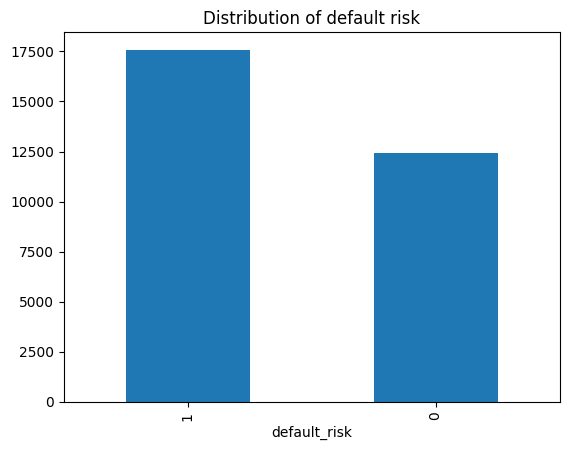

In [4]:
#EDA
#TARGET DISTRIBUTION
df['default_risk'].value_counts().plot(kind='bar')
plt.title('Distribution of default risk')
plt.show()

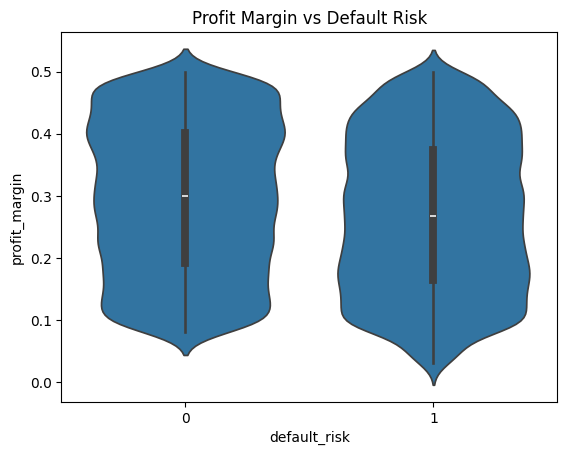

In [5]:
# feature vs target
sns.violinplot(x="default_risk", y="profit_margin", data=df)
plt.title("Profit Margin vs Default Risk")
plt.show()

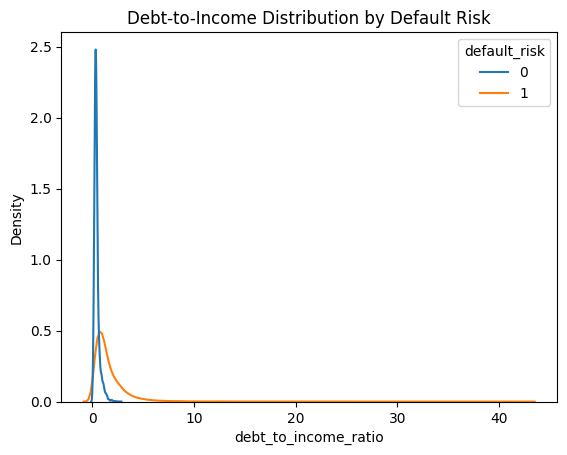

In [6]:
sns.kdeplot(data=df, x="debt_to_income_ratio", hue="default_risk", common_norm=False)
plt.title("Debt-to-Income Distribution by Default Risk")
plt.show()

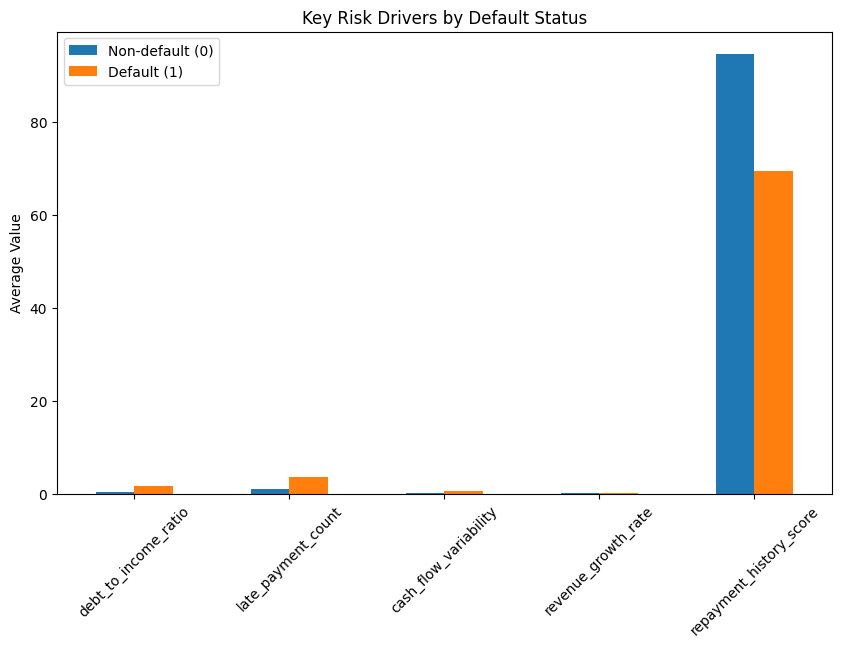

In [7]:
features = [
    "debt_to_income_ratio",
    "late_payment_count",
    "cash_flow_variability",
    "revenue_growth_rate",
    "repayment_history_score"
]

grouped = df.groupby("default_risk")[features].mean().T

grouped.plot(kind="bar", figsize=(10,6))
plt.title("Key Risk Drivers by Default Status")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(["Non-default (0)", "Default (1)"])
plt.show()

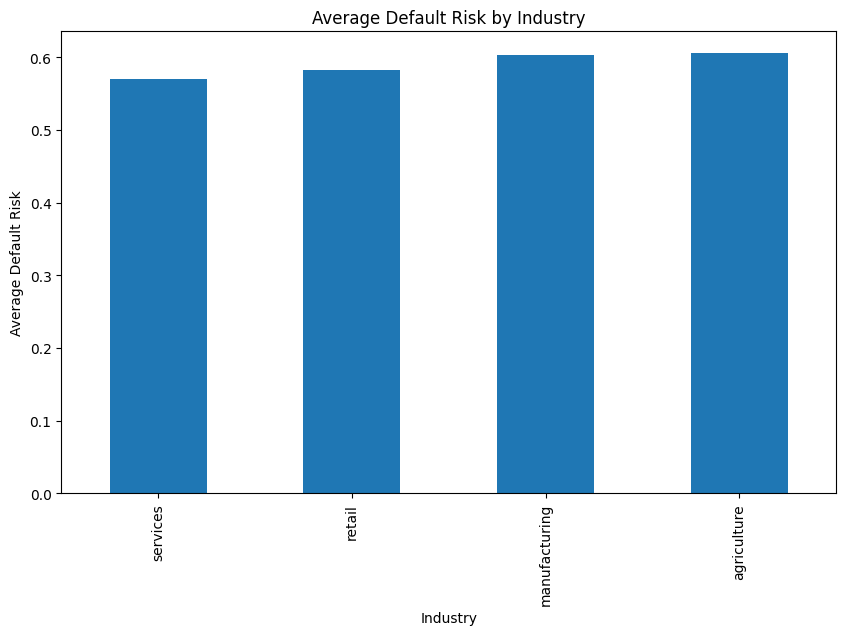

In [8]:
industry_risk = df.groupby('industry')['default_risk'].mean().sort_values()
industry_risk.plot(kind='bar', figsize=(10,6))
plt.title('Average Default Risk by Industry')
plt.ylabel('Average Default Risk')
plt.xlabel('Industry')
plt.show()

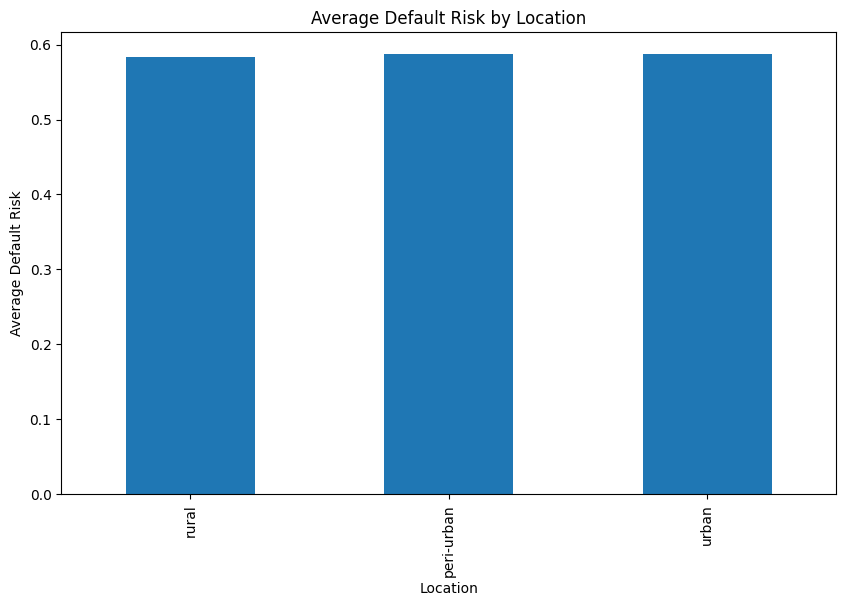

In [9]:
location_risk=df.groupby('location')['default_risk'].mean().sort_values()
location_risk.plot(kind='bar', figsize=(10,6))
plt.title('Average Default Risk by Location')
plt.ylabel('Average Default Risk')
plt.xlabel('Location')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
x = df.drop(columns = ['default_risk', 'business_persona'])
y = df['default_risk']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25,
                                                    random_state=42, stratify=y)

In [11]:
def feature_engineering(df):
    df = df.copy()

    df["debt_pressure"] = df["debt_to_income_ratio"] * df["cash_flow_variability"]
    df["profit_stability"] = df["profit_margin"] / (df["revenue_volatility"] + 0.01)
    df["repayment_risk"] = df["missed_payments"] / (df["repayment_history_score"] + 1)
    df["profit_risk"] = (1 - df["profit_margin"]) * df["debt_to_income_ratio"]
    df["cashflow_stress"] = df["cash_flow_variability"] * df["debt_to_income_ratio"]

    return df

x_train = feature_engineering(x_train)
x_test = feature_engineering(x_test)

In [12]:
#clustering by behaviour
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = [
    "profit_margin",
    "debt_to_income_ratio",
    "cash_flow_variability",
    "revenue_growth_rate",
    "repayment_history_score",
    "revenue_volatility"
]

scaler_cluster = StandardScaler()
x_train_cluster = scaler_cluster.fit_transform(x_train[cluster_features])
x_test_cluster = scaler_cluster.transform(x_test[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_model = kmeans.fit(x_train_cluster)

x_train["cluster"] = kmeans_model.predict(x_train_cluster)
x_test["cluster"] = kmeans_model.predict(x_test_cluster)

In [13]:
#handling categorrical and numerical variables

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical = ['industry', 'location']
numerical = [col for col in x_train.columns if col not in categorical]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ]
)

In [14]:
# model training
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.2,
        min_child_weight=3,
        reg_alpha=0.1,      
        reg_lambda=1.0,    
        random_state=42,
        eval_metric='logloss'
    ))
])

In [15]:
#random search for hyperparemeter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "classifier__n_estimators": [200, 300, 500, 700],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.6, 0.8, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0],
    "classifier__gamma": [0, 0.1, 0.3],
}

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=40,   # slightly more exploration
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(x_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.6, 0.8, ...], 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscro

In [16]:
# evaluation

from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

best_model = search.best_estimator_

y_prob = best_model.predict_proba(x_test)[:, 1]
y_pred = best_model.predict(x_test)

print("AUC:", roc_auc_score(y_test, y_prob))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

AUC: 0.9388862766526269
Accuracy: 0.8665333333333334
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      3104
           1       0.90      0.87      0.88      4396

    accuracy                           0.87      7500
   macro avg       0.86      0.87      0.86      7500
weighted avg       0.87      0.87      0.87      7500

[[2695  409]
 [ 592 3804]]


In [17]:
import joblib
joblib.dump(best_model, "credit_risk_model.pkl")
joblib.dump(kmeans_model, 'kmeans_model.pkl')

training_features = x_train.columns.tolist()
joblib.dump(training_features, "training_features.pkl")


['training_features.pkl']

In [ ]:
"""
SME Credit Risk Intelligence Platform
======================================
XGBoost-powered credit risk scoring for Small & Medium Enterprises.
Supports single SME assessment and batch portfolio analysis.

Requirements:
    pip install streamlit pandas numpy plotly joblib xgboost scikit-learn openpyxl
"""

import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import joblib
import hashlib
import io
import warnings
warnings.filterwarnings("ignore")

# ─── PAGE CONFIG ──────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="SME Credit Risk Intelligence",
    page_icon="🏦",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─── THEME ────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
  @import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@300;400;500;600;700&family=Space+Mono:wght@400;700&display=swap');

  html, body, [class*="css"] { font-family: 'Space Grotesk', sans-serif; }

  .stApp { background-color: #f8fafc; color: #1e293b; }

  /* ── Sidebar ── */
  [data-testid="stSidebar"] {
    background-color: #ffffff !important;
    border-right: 1px solid #e2e8f0;
  }
  [data-testid="stSidebar"] label,
  [data-testid="stSidebar"] p,
  [data-testid="stSidebar"] span { color: #64748b !important; }
  [data-testid="stSidebar"] .stSelectbox div[data-baseweb="select"] {
    background-color: #f8fafc !important;
  }

  /* ── Tabs ── */
  .stTabs [data-baseweb="tab-list"] {
    gap: 2px;
    background: #f1f5f9;
    border-radius: 10px;
    padding: 3px;
    border: 1px solid #e2e8f0;
  }
  .stTabs [data-baseweb="tab"] {
    color: #94a3b8;
    font-family: 'Space Grotesk', sans-serif;
    font-size: 13px;
    font-weight: 500;
    border-radius: 8px;
    padding: 8px 20px;
  }
  .stTabs [aria-selected="true"] {
    background-color: #1d4ed8 !important;
    color: #ffffff !important;
    font-weight: 600 !important;
  }

  /* ── Metric cards ── */
  div[data-testid="stMetric"] {
    background: #ffffff;
    border: 1px solid #e2e8f0;
    border-radius: 12px;
    padding: 16px 20px;
    box-shadow: 0 1px 3px rgba(0,0,0,0.04);
  }
  div[data-testid="stMetric"] label {
    color: #94a3b8 !important;
    font-size: 10px !important;
    font-family: 'Space Mono', monospace !important;
    text-transform: uppercase !important;
    letter-spacing: 0.12em !important;
  }
  div[data-testid="stMetricValue"] {
    color: #1d4ed8 !important;
    font-family: 'Space Mono', monospace !important;
    font-size: 26px !important;
  }

  /* ── Verdict card ── */
  .verdict-card {
    border-radius: 20px;
    padding: 40px 48px;
    text-align: center;
    position: relative;
    overflow: hidden;
    margin-bottom: 8px;
  }
  .verdict-low {
    background: linear-gradient(135deg, #f0fdf4 0%, #dcfce7 100%);
    border: 1.5px solid #86efac;
  }
  .verdict-moderate {
    background: linear-gradient(135deg, #fffbeb 0%, #fef3c7 100%);
    border: 1.5px solid #fcd34d;
  }
  .verdict-high {
    background: linear-gradient(135deg, #fff1f2 0%, #ffe4e6 100%);
    border: 1.5px solid #fca5a5;
  }
  .verdict-eyebrow {
    font-family: 'Space Mono', monospace;
    font-size: 10px;
    letter-spacing: 0.3em;
    text-transform: uppercase;
    margin-bottom: 14px;
  }
  .verdict-score {
    font-family: 'Space Mono', monospace;
    font-size: 80px;
    font-weight: 700;
    line-height: 1;
    margin-bottom: 8px;
  }
  .verdict-label {
    font-family: 'Space Grotesk', sans-serif;
    font-size: 20px;
    font-weight: 600;
    margin-bottom: 16px;
  }
  .verdict-pd {
    font-family: 'Space Mono', monospace;
    font-size: 14px;
    color: #64748b;
  }

  /* ── Sections ── */
  .section-label {
    font-family: 'Space Mono', monospace;
    font-size: 10px;
    letter-spacing: 0.2em;
    text-transform: uppercase;
    color: #94a3b8;
    margin-bottom: 16px;
    padding-bottom: 10px;
    border-bottom: 1px solid #e2e8f0;
  }

  /* ── Risk factor rows ── */
  .risk-row {
    display: flex;
    align-items: center;
    background: #ffffff;
    border: 1px solid #e2e8f0;
    border-radius: 10px;
    padding: 14px 18px;
    margin-bottom: 8px;
    box-shadow: 0 1px 2px rgba(0,0,0,0.03);
  }
  .risk-row-label { font-size: 13px; font-weight: 500; color: #475569; flex: 1; }
  .risk-row-value {
    font-family: 'Space Mono', monospace;
    font-size: 14px;
    font-weight: 700;
    min-width: 70px;
    text-align: right;
  }
  .risk-bar-wrap {
    flex: 1;
    background: #f1f5f9;
    border-radius: 3px;
    height: 5px;
    margin: 0 14px;
    max-width: 200px;
  }
  .risk-bar { height: 5px; border-radius: 3px; }

  /* ── Persona card ── */
  .persona-card {
    background: #ffffff;
    border: 1px solid #e2e8f0;
    border-radius: 14px;
    padding: 24px 28px;
    height: 100%;
    box-shadow: 0 1px 3px rgba(0,0,0,0.04);
  }
  .persona-icon { font-size: 36px; margin-bottom: 12px; }
  .persona-name {
    font-family: 'Space Grotesk', sans-serif;
    font-size: 20px;
    font-weight: 700;
    color: #1e293b;
    margin-bottom: 8px;
  }
  .persona-desc { font-size: 13px; color: #64748b; line-height: 1.7; }

  /* ── Info box ── */
  .info-box {
    background: #eff6ff;
    border-left: 3px solid #1d4ed8;
    border-radius: 0 8px 8px 0;
    padding: 12px 16px;
    font-size: 13px;
    color: #475569;
    line-height: 1.6;
    margin-top: 8px;
  }

  /* ── Batch table ── */
  .stDataFrame { background: #ffffff !important; }

  /* ── Buttons ── */
  .stButton > button {
    background: linear-gradient(135deg, #1d4ed8, #2563eb) !important;
    color: #ffffff !important;
    border: none !important;
    border-radius: 8px !important;
    font-weight: 600 !important;
    font-family: 'Space Grotesk', sans-serif !important;
    padding: 10px 28px !important;
    letter-spacing: 0.03em !important;
  }
  .stButton > button:hover {
    background: linear-gradient(135deg, #2563eb, #3b82f6) !important;
    transform: translateY(-1px);
    box-shadow: 0 4px 20px rgba(29,78,216,0.25) !important;
  }

  /* ── Number inputs / sliders ── */
  .stNumberInput input, .stTextInput input {
    background: #ffffff !important;
    border: 1px solid #e2e8f0 !important;
    color: #1e293b !important;
    border-radius: 8px !important;
  }
  .stSelectbox div[data-baseweb="select"] > div {
    background: #ffffff !important;
    border-color: #e2e8f0 !important;
    color: #1e293b !important;
  }

  /* ── Expander ── */
  .streamlit-expanderHeader {
    background: #ffffff !important;
    color: #64748b !important;
    border-radius: 10px !important;
    border: 1px solid #e2e8f0 !important;
  }

  footer, #MainMenu { visibility: hidden; }
</style>
""", unsafe_allow_html=True)


# ─── MODEL LOADING ────────────────────────────────────────────────────────────
@st.cache_resource
def load_models():
    try:
        model             = joblib.load("credit_risk_model.pkl")
        kmeans            = joblib.load("kmeans_model.pkl")
        training_features = joblib.load("training_features.pkl")
        return model, kmeans, training_features, None
    except Exception as e:
        return None, None, None, str(e)

model, kmeans_model, training_features, model_err = load_models()


# ─── COLUMN STANDARDISATION ───────────────────────────────────────────────────
COLUMN_MAPPING = {
    "monthly_revenue_avg":     ["revenue", "sales", "turnover", "income"],
    "monthly_expenses_avg":    ["expenses", "costs", "monthly_expenses"],
    "total_debt":              ["debt", "liabilities", "loan_balance"],
    "years_in_operation":      ["business_age", "years_active"],
    "num_transactions_per_month": ["transactions", "monthly_transactions"],
    "avg_transaction_value":   ["average_transaction"],
    "late_payment_count":      ["late_payments"],
    "missed_payments":         ["defaults", "missed_installments"],
    "industry":                ["sector"],
    "location":                ["business_location"],
}

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.lower().str.strip()
    rename = {}
    for std, variants in COLUMN_MAPPING.items():
        for col in df.columns:
            if col in variants:
                rename[col] = std
    return df.rename(columns=rename)


# ─── FEATURE ENGINEERING (deterministic — no random noise) ───────────────────
INDUSTRY_RISK = {
    "retail": 0.40, "services": 0.30,
    "manufacturing": 0.50, "agriculture": 0.45,
    "technology": 0.25, "construction": 0.55,
    "hospitality": 0.48, "transport": 0.42,
}

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    rev  = df.get("monthly_revenue_avg",  pd.Series([1]*len(df)))
    exp  = df.get("monthly_expenses_avg", pd.Series([0]*len(df)))
    debt = df.get("total_debt",           pd.Series([0]*len(df)))
    late = df.get("late_payment_count",   pd.Series([0]*len(df)))
    miss = df.get("missed_payments",      pd.Series([0]*len(df)))

    df["profit_margin"]         = (rev - exp) / (rev.abs() + 1)
    df["debt_to_income_ratio"]  = debt / (rev + 1)
    df["repayment_history_score"] = (100 - miss * 10).clip(0, 100)
    df["payment_stress"]        = late + miss
    df["stress_index"]          = (
        df["debt_to_income_ratio"]
        + df["payment_stress"] / 10
        + (exp / (rev + 1)).clip(0, 2)
    )
    df["liquidity_risk"]        = (df["debt_to_income_ratio"] * (exp / (rev + 1))).clip(0, 5)

    # Derived volatility proxies (deterministic from existing data)
    df["cash_flow_variability"] = (exp / (rev + 1)).clip(0.05, 0.95)
    df["revenue_volatility"]    = df["cash_flow_variability"] * rev
    df["declining_revenue_trend"] = (df["profit_margin"] < 0).astype(int)
    df["expense_spikes"]        = (exp > rev * 0.9).astype(int)
    df["cash_flow_gaps"]        = df["payment_stress"].clip(0, 5)
    df["revenue_growth_rate"]   = df["profit_margin"].clip(-0.2, 0.3)

    if "industry" in df.columns:
        df["industry"] = df["industry"].str.lower().str.strip()
        df["industry_risk"] = df["industry"].map(INDUSTRY_RISK).fillna(0.38)
    else:
        df["industry_risk"] = 0.38

    return df


# ─── PERSONA ASSIGNMENT ───────────────────────────────────────────────────────
PERSONAS = {
    "stable": {
        "icon": "🏛️",
        "name": "Stable SME",
        "color": "#22c55e",
        "desc": "Consistent revenue, manageable debt load, strong repayment history. "
                "Low default probability. Suitable for standard credit products.",
    },
    "growth": {
        "icon": "🚀",
        "name": "Growth SME",
        "color": "#38bdf8",
        "desc": "Revenue expansion trajectory. Elevated debt-to-income is expected "
                "for the growth stage. Monitor cash flow discipline closely.",
    },
    "seasonal": {
        "icon": "🔄",
        "name": "Seasonal SME",
        "color": "#f59e0b",
        "desc": "Revenue fluctuates with seasonal cycles. Risk spikes during off-peak "
                "periods. Structure repayment schedules around income seasonality.",
    },
    "distressed": {
        "icon": "⚠️",
        "name": "Distressed SME",
        "color": "#ef4444",
        "desc": "High stress index, payment irregularities, compressed margins. "
                "Requires enhanced due diligence and potentially collateral-backed terms.",
    },
}

def assign_persona(row: pd.Series) -> str:
    if row["profit_margin"] > 0.25 and row["debt_to_income_ratio"] < 0.5:
        return "stable"
    elif row.get("revenue_growth_rate", 0) > 0.15:
        return "growth"
    elif row["stress_index"] > 1.5:
        return "distressed"
    else:
        return "seasonal"


# ─── CREDIT SCORE + RISK BAND ─────────────────────────────────────────────────
def score_from_pd(pd_prob: float) -> int:
    return max(100, min(1000, int((1 - pd_prob) * 1000)))

def risk_band(pd_prob: float):
    if pd_prob < 0.10:
        return "Low Risk",      "#22c55e", "verdict-low",      "✅"
    elif pd_prob < 0.30:
        return "Moderate Risk", "#f59e0b", "verdict-moderate", "⚠️"
    else:
        return "High Risk",     "#ef4444", "verdict-high",     "🚨"


# ─── RISK DRIVER TABLE ────────────────────────────────────────────────────────
def build_risk_drivers(row: pd.Series) -> list:
    drivers = [
        ("Debt-to-Income Ratio",       row.get("debt_to_income_ratio", 0),  2.0,  "Higher = more leveraged"),
        ("Stress Index",               row.get("stress_index", 0),           3.0,  "Composite financial pressure score"),
        ("Liquidity Risk",             row.get("liquidity_risk", 0),         2.0,  "Cash flow vs debt exposure"),
        ("Payment Stress",             row.get("payment_stress", 0),         10.0, "Late + missed payments combined"),
        ("Expense Pressure",           row.get("cash_flow_variability", 0),  1.0,  "Expenses as share of revenue"),
    ]
    result = []
    for name, val, max_val, note in drivers:
        pct = min(val / max_val, 1.0) * 100
        color = "#ef4444" if pct > 70 else "#f59e0b" if pct > 40 else "#22c55e"
        result.append({"name": name, "val": val, "pct": pct, "color": color, "note": note})
    return result


# ─── BENCHMARK RADAR ──────────────────────────────────────────────────────────
INDUSTRY_BENCHMARKS = {
    "retail":        {"Profit Margin": 0.18, "DTI Ratio": 0.60, "Repayment Score": 72, "Liquidity": 0.30},
    "services":      {"Profit Margin": 0.28, "DTI Ratio": 0.45, "Repayment Score": 80, "Liquidity": 0.20},
    "manufacturing": {"Profit Margin": 0.15, "DTI Ratio": 0.70, "Repayment Score": 68, "Liquidity": 0.40},
    "agriculture":   {"Profit Margin": 0.12, "DTI Ratio": 0.55, "Repayment Score": 65, "Liquidity": 0.45},
    "technology":    {"Profit Margin": 0.35, "DTI Ratio": 0.35, "Repayment Score": 85, "Liquidity": 0.15},
}
DEFAULT_BENCHMARK = {"Profit Margin": 0.20, "DTI Ratio": 0.58, "Repayment Score": 72, "Liquidity": 0.30}

CHART_LAYOUT = dict(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="#f8fafc",
    font=dict(family="Space Grotesk, sans-serif", color="#94a3b8", size=11),
    margin=dict(l=0, r=0, t=36, b=0),
)


def chart_radar(row: pd.Series) -> go.Figure:
    industry = str(row.get("industry", "")).lower()
    bench = INDUSTRY_BENCHMARKS.get(industry, DEFAULT_BENCHMARK)

    cats    = list(bench.keys())
    sme_raw = [
        max(0, row.get("profit_margin", 0)),
        max(0, 1 - min(row.get("debt_to_income_ratio", 0) / 2, 1)),
        row.get("repayment_history_score", 75) / 100,
        max(0, 1 - min(row.get("liquidity_risk", 0), 1)),
    ]
    bench_raw = [
        bench["Profit Margin"],
        1 - bench["DTI Ratio"] / 2,
        bench["Repayment Score"] / 100,
        1 - bench["Liquidity"],
    ]

    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
        r=bench_raw + [bench_raw[0]],
        theta=cats + [cats[0]],
        name="Industry Avg",
        fill="toself",
        fillcolor="rgba(14,77,145,0.1)",
        line=dict(color="#0e4d91", width=1.5, dash="dot"),
    ))
    fig.add_trace(go.Scatterpolar(
        r=sme_raw + [sme_raw[0]],
        theta=cats + [cats[0]],
        name="This SME",
        fill="toself",
        fillcolor="rgba(79,195,247,0.12)",
        line=dict(color="#4fc3f7", width=2),
    ))
    radar_layout = {k: v for k, v in CHART_LAYOUT.items() if k != "margin"}
    fig.update_layout(
        **radar_layout,
        polar=dict(
            bgcolor="#f8fafc",
            radialaxis=dict(visible=True, range=[0, 1], gridcolor="#e2e8f0",
                            tickfont=dict(size=9, color="#94a3b8")),
            angularaxis=dict(gridcolor="#e2e8f0", tickfont=dict(size=11, color="#64748b")),
        ),
        legend=dict(bgcolor="rgba(0,0,0,0)", bordercolor="#e2e8f0", borderwidth=1,
                    font=dict(color="#64748b")),
        height=320,
        margin=dict(l=20, r=20, t=20, b=20),
    )
    return fig


def chart_portfolio_risk(batch_df: pd.DataFrame) -> go.Figure:
    counts = batch_df["Risk Level"].value_counts().reindex(
        ["Low Risk", "Moderate Risk", "High Risk"], fill_value=0)
    colors = {"Low Risk": "#22c55e", "Moderate Risk": "#f59e0b", "High Risk": "#ef4444"}
    fig = go.Figure(go.Bar(
        x=counts.index,
        y=counts.values,
        marker_color=[colors[k] for k in counts.index],
        marker_line_width=0,
        text=counts.values,
        textposition="outside",
        textfont=dict(color="#64748b", size=13, family="Space Mono"),
        hovertemplate="%{x}: <b>%{y} SMEs</b><extra></extra>",
    ))
    fig.update_layout(
        **CHART_LAYOUT,
        title=dict(text="Portfolio Risk Distribution", font=dict(size=13, color="#94a3b8")),
        xaxis=dict(gridcolor="#e2e8f0"),
        yaxis=dict(gridcolor="#e2e8f0"),
        height=280,
    )
    return fig


def chart_score_histogram(batch_df: pd.DataFrame) -> go.Figure:
    fig = go.Figure(go.Histogram(
        x=batch_df["Credit Score"],
        nbinsx=20,
        marker_color="#0e4d91",
        marker_line_color="#4fc3f7",
        marker_line_width=0.5,
        hovertemplate="Score %{x}: <b>%{y} SMEs</b><extra></extra>",
    ))
    fig.update_layout(
        **CHART_LAYOUT,
        title=dict(text="Credit Score Distribution", font=dict(size=13, color="#94a3b8")),
        xaxis=dict(gridcolor="#e2e8f0"),
        yaxis=dict(gridcolor="#e2e8f0"),
        height=280,
    )
    return fig


def chart_pd_scatter(batch_df: pd.DataFrame) -> go.Figure:
    color_map = {"Low Risk": "#22c55e", "Moderate Risk": "#f59e0b", "High Risk": "#ef4444"}
    fig = go.Figure()
    for label, color in color_map.items():
        sub = batch_df[batch_df["Risk Level"] == label]
        if len(sub) == 0:
            continue
        fig.add_trace(go.Scatter(
            x=sub["Credit Score"],
            y=sub["PD (%)"],
            mode="markers",
            name=label,
            marker=dict(color=color, size=8, opacity=0.8,
                        line=dict(color="rgba(0,0,0,0.3)", width=0.5)),
            hovertemplate="<b>%{text}</b><br>Score: %{x}<br>PD: %{y:.1f}%<extra></extra>",
            text=sub.get("sme_name", sub.index).astype(str),
        ))
    fig.update_layout(
        **CHART_LAYOUT,
        title=dict(text="Credit Score vs Probability of Default", font=dict(size=13, color="#94a3b8")),
        xaxis=dict(title="Credit Score", gridcolor="#e2e8f0"),
        yaxis=dict(title="PD (%)", gridcolor="#e2e8f0"),
        legend=dict(bgcolor="rgba(0,0,0,0)", bordercolor="#e2e8f0", font=dict(color="#64748b")),
        height=320,
    )
    return fig


# ─── SCORE A SINGLE ROW ───────────────────────────────────────────────────────
def score_row(row_dict: dict, model, training_features) -> dict:
    df = pd.DataFrame([row_dict])
    df = standardize_columns(df)
    df = engineer_features(df)
    X  = df.reindex(columns=training_features, fill_value=0)
    pd_prob = float(model.predict_proba(X)[0][1])
    persona = assign_persona(df.iloc[0])
    return {
        "pd_prob":   pd_prob,
        "score":     score_from_pd(pd_prob),
        "risk":      risk_band(pd_prob)[0],
        "persona":   persona,
        "drivers":   build_risk_drivers(df.iloc[0]),
        "row":       df.iloc[0],
    }


# ─── DEMO DATA GENERATOR ─────────────────────────────────────────────────────
@st.cache_data
def make_demo_batch(n: int = 12) -> pd.DataFrame:
    rng = np.random.default_rng(99)
    names = [
        "Mama Mboga Fresh Supplies", "TechHub Nairobi Ltd", "Savanna Transport Co.",
        "Kilimo Bora Farms", "Jua Kali Metal Works", "SwiftPay Solutions",
        "East Africa Builders", "Furaha Restaurant Group", "Nexus IT Services",
        "Coastal Fishing Co.", "Karibu Hospitality Ltd", "MadeSmart Apparel",
    ]
    industries = ["retail", "technology", "transport", "agriculture",
                  "manufacturing", "technology", "construction",
                  "hospitality", "technology", "agriculture",
                  "hospitality", "retail"]
    rows = []
    for i in range(min(n, len(names))):
        rev  = rng.integers(50_000, 800_000)
        exp  = int(rev * rng.uniform(0.4, 0.95))
        debt = int(rev * rng.uniform(0.2, 3.5))
        rows.append({
            "sme_name":                names[i],
            "monthly_revenue_avg":     rev,
            "monthly_expenses_avg":    exp,
            "total_debt":              debt,
            "years_in_operation":      int(rng.integers(1, 15)),
            "num_transactions_per_month": int(rng.integers(10, 300)),
            "avg_transaction_value":   int(rev / rng.integers(20, 100)),
            "late_payment_count":      int(rng.integers(0, 8)),
            "missed_payments":         int(rng.integers(0, 4)),
            "industry":                industries[i],
            "location":                rng.choice(["Nairobi", "Mombasa", "Kisumu", "Nakuru"]),
        })
    return pd.DataFrame(rows)


# ─── SIDEBAR ──────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style="margin-bottom:28px;">
      <div style="font-family:'Space Mono',monospace;font-size:10px;letter-spacing:0.2em;
                  color:#1d4ed8;text-transform:uppercase;margin-bottom:6px;">Risk Engine</div>
      <div style="font-family:'Space Grotesk',sans-serif;font-size:22px;font-weight:700;
                  color:#1e293b;">SME Credit Risk</div>
      <div style="font-size:12px;color:#94a3b8;margin-top:3px;">Intelligence Platform</div>
    </div>
    """, unsafe_allow_html=True)

    mode = st.radio("Mode", ["Single SME Assessment", "Batch Portfolio Upload"],
                    label_visibility="collapsed")

    if mode == "Batch Portfolio Upload":
        batch_file = st.file_uploader("Upload CSV / Excel", type=["csv", "xlsx"])
        use_demo_batch = st.checkbox("Use demo portfolio (12 SMEs)", value=True)
    else:
        batch_file    = None
        use_demo_batch = False

    st.markdown("---")

    if model_err:
        st.error(f"⚠ Model load failed:\n{model_err}")
        st.info("Ensure `credit_risk_model.pkl`, `kmeans_model.pkl`, and `training_features.pkl` are in the repo root.")
    else:
        st.markdown("""
        <div style="font-size:12px;color:#94a3b8;line-height:1.9;">
          <b style="color:#64748b;">Model</b><br>XGBoost Classifier<br><br>
          <b style="color:#64748b;">Segmentation</b><br>KMeans Clustering<br><br>
          <b style="color:#64748b;">Score Range</b><br>100 (highest risk) → 1000 (lowest risk)<br><br>
          <b style="color:#64748b;">Risk Bands</b><br>
          🟢 Low &nbsp;&lt; 10% PD<br>
          🟡 Moderate &nbsp;10–30% PD<br>
          🔴 High &nbsp;&gt; 30% PD
        </div>
        """, unsafe_allow_html=True)


# ─── HERO ─────────────────────────────────────────────────────────────────────
st.markdown("""
<div style="margin-bottom:32px;">
  <div style="font-family:'Space Mono',monospace;font-size:10px;letter-spacing:0.25em;
              color:#1d4ed8;text-transform:uppercase;margin-bottom:10px;">
    AI-Driven Underwriting
  </div>
  <div style="font-family:'Space Grotesk',sans-serif;font-size:38px;font-weight:700;
              color:#1e293b;line-height:1.15;margin-bottom:12px;">
    SME Credit Risk<br>Intelligence Platform
  </div>
  <div style="font-size:14px;color:#64748b;max-width:560px;line-height:1.7;">
    XGBoost-powered probability of default estimation, credit scoring,
    and behavioural SME profiling — built for East African fintech and lending environments.
  </div>
</div>
""", unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# SINGLE SME ASSESSMENT MODE
# ══════════════════════════════════════════════════════════════════════════════
if mode == "Single SME Assessment":

    if model_err:
        st.stop()

    st.markdown("<div class='section-label'>Business Profile</div>", unsafe_allow_html=True)

    with st.form("sme_form"):
        c1, c2, c3 = st.columns(3)
        sme_name    = c1.text_input("Business Name", value="Acme SME Ltd")
        industry    = c2.selectbox("Industry", list(INDUSTRY_RISK.keys()), index=0)
        location    = c3.selectbox("Location", ["Nairobi", "Mombasa", "Kisumu", "Nakuru", "Other"])

        st.markdown("<div style='height:16px'></div>", unsafe_allow_html=True)
        st.markdown("<div class='section-label'>Financials (Monthly, KES)</div>", unsafe_allow_html=True)

        f1, f2, f3 = st.columns(3)
        revenue  = f1.number_input("Monthly Revenue",    min_value=0, value=200_000, step=10_000)
        expenses = f2.number_input("Monthly Expenses",   min_value=0, value=140_000, step=10_000)
        debt     = f3.number_input("Total Outstanding Debt", min_value=0, value=300_000, step=10_000)

        st.markdown("<div style='height:16px'></div>", unsafe_allow_html=True)
        st.markdown("<div class='section-label'>Payment Behaviour</div>", unsafe_allow_html=True)

        p1, p2, p3, p4 = st.columns(4)
        years       = p1.number_input("Years in Operation", min_value=0, value=4, step=1)
        transactions = p2.number_input("Transactions/Month", min_value=0, value=80, step=5)
        late_pays   = p3.number_input("Late Payment Count", min_value=0, value=2, step=1)
        missed_pays = p4.number_input("Missed Payments",    min_value=0, value=0, step=1)

        submitted = st.form_submit_button("▶  Run Credit Assessment", use_container_width=True)

    if submitted:
        input_dict = {
            "sme_name":                    sme_name,
            "monthly_revenue_avg":         revenue,
            "monthly_expenses_avg":        expenses,
            "total_debt":                  debt,
            "years_in_operation":          years,
            "num_transactions_per_month":  transactions,
            "avg_transaction_value":       revenue / max(transactions, 1),
            "late_payment_count":          late_pays,
            "missed_payments":             missed_pays,
            "industry":                    industry,
            "location":                    location,
        }

        with st.spinner("Running XGBoost inference…"):
            result = score_row(input_dict, model, training_features)

        pd_prob  = result["pd_prob"]
        score    = result["score"]
        label, color, css_class, icon = risk_band(pd_prob)
        persona  = result["persona"]
        row      = result["row"]

        st.markdown("<br>", unsafe_allow_html=True)

        # ── VERDICT ────────────────────────────────────────────────────────
        col_v, col_r = st.columns([1, 1], gap="large")

        with col_v:
            st.markdown(f"""
            <div class="verdict-card {css_class}">
              <div class="verdict-eyebrow" style="color:{color};">Credit Assessment Verdict</div>
              <div class="verdict-score" style="color:{color};">{score}</div>
              <div class="verdict-label" style="color:{color};">{icon} {label}</div>
              <div class="verdict-pd">Probability of Default: {pd_prob:.1%}</div>
              <div style="margin-top:20px;font-size:12px;color:#94a3b8;
                          font-family:'Space Mono',monospace;">
                {sme_name}
              </div>
            </div>
            """, unsafe_allow_html=True)

        with col_r:
            st.markdown("<div class='section-label'>Key Risk Drivers</div>", unsafe_allow_html=True)
            for d in result["drivers"]:
                st.markdown(f"""
                <div class="risk-row">
                  <div class="risk-row-label">{d['name']}<br>
                    <span style="font-size:11px;color:#2a4a6a;">{d['note']}</span>
                  </div>
                  <div class="risk-bar-wrap">
                    <div class="risk-bar" style="width:{d['pct']:.0f}%;background:{d['color']};"></div>
                  </div>
                  <div class="risk-row-value" style="color:{d['color']};">{d['val']:.2f}</div>
                </div>
                """, unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)

        # ── PERSONA + BENCHMARK ────────────────────────────────────────────
        col_p, col_b = st.columns([1, 1], gap="large")

        with col_p:
            p = PERSONAS[persona]
            st.markdown("<div class='section-label'>Behavioural Persona</div>", unsafe_allow_html=True)
            st.markdown(f"""
            <div class="persona-card">
              <div class="persona-icon">{p['icon']}</div>
              <div class="persona-name" style="color:{p['color']};">{p['name']}</div>
              <div class="persona-desc">{p['desc']}</div>
              <div style="margin-top:20px;font-size:11px;color:#94a3b8;
                          font-family:'Space Mono',monospace;">
                INDUSTRY · {industry.upper()}
              </div>
            </div>
            """, unsafe_allow_html=True)

        with col_b:
            st.markdown("<div class='section-label'>Industry Benchmark Radar</div>",
                        unsafe_allow_html=True)
            st.plotly_chart(chart_radar(row), use_container_width=True,
                            config={"displayModeBar": False})

        # ── UNDERWRITER SUMMARY ────────────────────────────────────────────
        st.markdown("<br>", unsafe_allow_html=True)
        with st.expander("📋 Underwriter Summary", expanded=True):
            profit_margin = row.get("profit_margin", 0)
            dti           = row.get("debt_to_income_ratio", 0)
            st.markdown(f"""
            <div style="color:#475569;font-size:13px;line-height:1.9;padding:8px 0;">
              <b style="color:#1d4ed8;">{sme_name}</b> operates in the
              <b style="color:#1e293b;">{industry}</b> sector with a monthly revenue of
              <b style="color:#1e293b;">KES {revenue:,}</b> and expenses of
              <b style="color:#1e293b;">KES {expenses:,}</b>,
              yielding a profit margin of
              <b style="color:{'#16a34a' if profit_margin > 0.15 else '#dc2626'};">
              {profit_margin:.1%}</b>.<br><br>
              The debt-to-income ratio of <b style="color:{'#16a34a' if dti < 0.6 else '#dc2626'};">
              {dti:.2f}x</b> {'is within acceptable thresholds' if dti < 0.6 else 'exceeds standard thresholds and warrants scrutiny'}.
              Payment behaviour shows <b style="color:#1e293b;">{late_pays} late</b> and
              <b style="color:#1e293b;">{missed_pays} missed payments</b>.
              {'No payment irregularities detected.' if missed_pays == 0 and late_pays < 3
               else 'Payment irregularities detected — recommend enhanced monitoring.'}<br><br>
              <b style="color:#1d4ed8;">Recommendation:</b>
              {'Standard credit terms applicable. Low monitoring frequency required.'
               if label == 'Low Risk'
               else 'Conditional credit approval. Require quarterly financial reporting.'
               if label == 'Moderate Risk'
               else 'Decline or require significant collateral. Refer to senior underwriter.'}
            </div>
            """, unsafe_allow_html=True)

        with st.expander("🔬 How the credit score is calculated", expanded=False):
            st.markdown("""
            <div style="color:#475569;font-size:13px;line-height:1.9;padding:8px 0;">
              <b style="color:#1d4ed8;">Model</b><br>
              XGBoost classifier trained on engineered SME financial features.
              Outputs a calibrated Probability of Default (PD) between 0 and 1.<br><br>
              <b style="color:#1d4ed8;">Credit Score Formula</b><br>
              <code style="background:#f1f5f9;padding:3px 8px;border-radius:4px;color:#1d4ed8;">
                Credit Score = (1 − PD) × 1000
              </code>
              &nbsp;clamped to [100, 1000].<br><br>
              <b style="color:#1d4ed8;">Risk Bands</b><br>
              PD &lt; 10% → Low Risk (Score 900–1000)<br>
              PD 10–30% → Moderate Risk (Score 700–900)<br>
              PD &gt; 30% → High Risk (Score &lt; 700)<br><br>
              <b style="color:#1d4ed8;">Features used</b><br>
              Debt-to-income ratio, profit margin, repayment history score,
              payment stress (late + missed), cash flow variability, liquidity risk,
              stress index, revenue volatility, industry risk weight, and others
              aligned to model training features.
            </div>
            """, unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# BATCH PORTFOLIO MODE
# ══════════════════════════════════════════════════════════════════════════════
else:
    if model_err:
        st.stop()

    # ── Load data ──────────────────────────────────────────────────────────
    if use_demo_batch or batch_file is None:
        raw_df = make_demo_batch()
        st.markdown("""
        <div style="background:#eff6ff;border:1px solid #bfdbfe;
                    border-radius:10px;padding:12px 18px;font-size:13px;color:#1d4ed8;
                    margin-bottom:20px;">
          📊 Demo portfolio loaded — 12 synthetic Kenyan SMEs across 6 sectors
        </div>
        """, unsafe_allow_html=True)
    else:
        if batch_file.name.endswith(".csv"):
            raw_df = pd.read_csv(batch_file)
        else:
            raw_df = pd.read_excel(batch_file)

    # ── VECTORISED batch scoring (single predict_proba call) ───────────────
    @st.cache_data
    def score_batch_vectorised(_model, _training_features, df_hash: str,
                                raw: pd.DataFrame) -> pd.DataFrame:
        """Score entire portfolio in one model call — fast regardless of size."""
        df = standardize_columns(raw.copy())
        df = engineer_features(df)
        X  = df.reindex(columns=_training_features, fill_value=0)
        pd_probs = _model.predict_proba(X)[:, 1]

        names = (raw.get("sme_name", pd.Series([f"SME {i}" for i in range(len(raw))]))
                 if "sme_name" in raw.columns
                 else pd.Series([f"SME {i}" for i in range(len(raw))]))

        rows = []
        for i, (pd_prob, eng_row) in enumerate(zip(pd_probs, df.itertuples())):
            label, color, css, icon = risk_band(float(pd_prob))
            persona_key  = assign_persona(df.iloc[i])
            persona_info = PERSONAS[persona_key]
            rows.append({
                "SME Name":     str(names.iloc[i]),
                "Industry":     str(raw.get("industry", pd.Series(["N/A"] * len(raw))).iloc[i]).title(),
                "Credit Score": score_from_pd(float(pd_prob)),
                "PD (%)":       round(float(pd_prob) * 100, 1),
                "Risk Level":   label,
                "Persona":      persona_info["name"],
                "_pd_prob":     float(pd_prob),
                "_persona_key": persona_key,
                "_eng_idx":     i,
            })
        result = pd.DataFrame(rows)
        result["_eng_df_json"] = df.to_json()  # carry engineered features for drill-down
        return result

    # Cache key = shape + column hash so re-uploads invalidate cache
    import hashlib
    df_hash = hashlib.md5(
        (str(raw_df.shape) + str(list(raw_df.columns))).encode()
    ).hexdigest()

    with st.spinner(f"Scoring {len(raw_df)} SMEs…"):
        scored_df = score_batch_vectorised(
            model, training_features, df_hash, raw_df)

    # Extract engineered df for drill-down
    eng_df = pd.read_json(io.StringIO(scored_df["_eng_df_json"].iloc[0]))
    display_df = scored_df.drop(
        columns=["_pd_prob", "_persona_key", "_eng_idx", "_eng_df_json"])

    # ── PORTFOLIO KPIs ─────────────────────────────────────────────────────
    n_total   = len(scored_df)
    n_low     = (scored_df["Risk Level"] == "Low Risk").sum()
    n_mod     = (scored_df["Risk Level"] == "Moderate Risk").sum()
    n_high    = (scored_df["Risk Level"] == "High Risk").sum()
    avg_score = scored_df["Credit Score"].mean()
    avg_pd    = scored_df["PD (%)"].mean()

    k1, k2, k3, k4, k5, k6 = st.columns(6)
    k1.metric("Total SMEs",       n_total)
    k2.metric("Avg Credit Score", f"{avg_score:.0f}")
    k3.metric("Avg PD",           f"{avg_pd:.1f}%")
    k4.metric("🟢 Low Risk",      n_low)
    k5.metric("🟡 Moderate",      n_mod)
    k6.metric("🔴 High Risk",     n_high)

    st.markdown("<br>", unsafe_allow_html=True)

    # ── CHARTS + TABLE + DRILL-DOWN ────────────────────────────────────────
    tab_port, tab_table, tab_drill = st.tabs([
        "📈  Portfolio Analytics", "📋  Scored Ledger", "🔍  SME Deep Dive"
    ])

    with tab_port:
        ch1, ch2 = st.columns(2, gap="large")
        with ch1:
            st.plotly_chart(chart_portfolio_risk(scored_df),
                            use_container_width=True, config={"displayModeBar": False})
        with ch2:
            st.plotly_chart(chart_score_histogram(scored_df),
                            use_container_width=True, config={"displayModeBar": False})
        st.markdown("<br>", unsafe_allow_html=True)
        st.plotly_chart(
            chart_pd_scatter(scored_df.rename(columns={"SME Name": "sme_name"})),
            use_container_width=True, config={"displayModeBar": False})

    with tab_table:
        st.markdown("<div class='section-label'>Scored Portfolio</div>",
                    unsafe_allow_html=True)

        def style_risk(val):
            colors = {"Low Risk": "#16a34a", "Moderate Risk": "#d97706",
                      "High Risk": "#dc2626"}
            return f"color: {colors.get(val, '#1e293b')}; font-weight: 600;"

        styled = display_df.style.map(style_risk, subset=["Risk Level"])
        st.dataframe(styled, use_container_width=True, hide_index=True)

        csv_bytes = display_df.to_csv(index=False).encode()
        st.download_button(
            label="⬇  Download Scored Portfolio (CSV)",
            data=csv_bytes,
            file_name="sme_credit_risk_scored.csv",
            mime="text/csv",
        )

    with tab_drill:
        st.markdown("<div class='section-label'>Select an SME for Full Credit Assessment</div>",
                    unsafe_allow_html=True)

        sme_options = scored_df["SME Name"].tolist()
        selected_sme = st.selectbox(
            "Choose SME", sme_options,
            format_func=lambda x: f"{x}  ·  Score: "
                f"{scored_df.loc[scored_df['SME Name']==x, 'Credit Score'].iloc[0]}"
                f"  ·  {scored_df.loc[scored_df['SME Name']==x, 'Risk Level'].iloc[0]}",
            label_visibility="collapsed",
        )

        if selected_sme:
            idx       = scored_df[scored_df["SME Name"] == selected_sme].index[0]
            sme_row   = scored_df.iloc[idx]
            eng_row   = eng_df.iloc[sme_row["_eng_idx"]]
            pd_prob   = sme_row["_pd_prob"]
            score     = sme_row["Credit Score"]
            label, color, css_class, icon = risk_band(pd_prob)
            persona   = sme_row["_persona_key"]
            industry  = sme_row["Industry"].lower()

            st.markdown("<br>", unsafe_allow_html=True)

            # Verdict + Risk Drivers
            col_v, col_r = st.columns([1, 1], gap="large")

            with col_v:
                st.markdown(f"""
                <div class="verdict-card {css_class}">
                  <div class="verdict-eyebrow" style="color:{color};">Credit Assessment Verdict</div>
                  <div class="verdict-score" style="color:{color};">{score}</div>
                  <div class="verdict-label" style="color:{color};">{icon} {label}</div>
                  <div class="verdict-pd">Probability of Default: {pd_prob:.1%}</div>
                  <div style="margin-top:20px;font-size:12px;color:#94a3b8;
                              font-family:'Space Mono',monospace;">{selected_sme}</div>
                </div>
                """, unsafe_allow_html=True)

            with col_r:
                st.markdown("<div class='section-label'>Key Risk Drivers</div>",
                            unsafe_allow_html=True)
                for d in build_risk_drivers(eng_row):
                    st.markdown(f"""
                    <div class="risk-row">
                      <div class="risk-row-label">{d['name']}<br>
                        <span style="font-size:11px;color:#94a3b8;">{d['note']}</span>
                      </div>
                      <div class="risk-bar-wrap">
                        <div class="risk-bar"
                             style="width:{d['pct']:.0f}%;background:{d['color']};"></div>
                      </div>
                      <div class="risk-row-value"
                           style="color:{d['color']};">{d['val']:.2f}</div>
                    </div>
                    """, unsafe_allow_html=True)

            st.markdown("<br>", unsafe_allow_html=True)

            # Persona + Radar
            col_p, col_b = st.columns([1, 1], gap="large")

            with col_p:
                p = PERSONAS[persona]
                st.markdown("<div class='section-label'>Behavioural Persona</div>",
                            unsafe_allow_html=True)
                st.markdown(f"""
                <div class="persona-card">
                  <div class="persona-icon">{p['icon']}</div>
                  <div class="persona-name" style="color:{p['color']};">{p['name']}</div>
                  <div class="persona-desc">{p['desc']}</div>
                  <div style="margin-top:20px;font-size:11px;color:#94a3b8;
                              font-family:'Space Mono',monospace;">
                    INDUSTRY · {industry.upper()}
                  </div>
                </div>
                """, unsafe_allow_html=True)

            with col_b:
                st.markdown("<div class='section-label'>Industry Benchmark Radar</div>",
                            unsafe_allow_html=True)
                st.plotly_chart(chart_radar(eng_row),
                                use_container_width=True,
                                config={"displayModeBar": False})

            # Underwriter summary
            st.markdown("<br>", unsafe_allow_html=True)
            with st.expander("📋 Underwriter Summary", expanded=True):
                pm  = float(eng_row.get("profit_margin", 0))
                dti = float(eng_row.get("debt_to_income_ratio", 0))
                lp  = int(eng_row.get("payment_stress", 0))
                st.markdown(f"""
                <div style="color:#475569;font-size:13px;line-height:1.9;padding:8px 0;">
                  <b style="color:#1d4ed8;">{selected_sme}</b> operates in the
                  <b style="color:#1e293b;">{industry}</b> sector with a profit margin of
                  <b style="color:{'#16a34a' if pm > 0.15 else '#dc2626'};">{pm:.1%}</b>.<br><br>
                  Debt-to-income ratio of
                  <b style="color:{'#16a34a' if dti < 0.6 else '#dc2626'};">{dti:.2f}x</b>
                  {'is within acceptable thresholds.' if dti < 0.6
                   else 'exceeds standard thresholds — warrants scrutiny.'}
                  Payment stress score: <b style="color:#1e293b;">{lp}</b>
                  {'— no irregularities.' if lp < 3 else '— irregularities detected, recommend enhanced monitoring.'}<br><br>
                  <b style="color:#1d4ed8;">Recommendation:</b>
                  {'Standard credit terms applicable.'
                   if label == 'Low Risk'
                   else 'Conditional approval. Require quarterly reporting.'
                   if label == 'Moderate Risk'
                   else 'Decline or require collateral. Refer to senior underwriter.'}
                </div>
                """, unsafe_allow_html=True)


# ─── FOOTER ───────────────────────────────────────────────────────────────────
st.markdown("""
<div style="margin-top:60px;padding:24px 0;border-top:1px solid #e2e8f0;
            display:flex;justify-content:space-between;align-items:center;">
  <div style="font-family:'Space Mono',monospace;font-size:10px;color:#cbd5e1;
              letter-spacing:0.1em;">
    SME CREDIT RISK INTELLIGENCE · XGBOOST + KMEANS
  </div>
  <div style="font-family:'Space Mono',monospace;font-size:10px;color:#cbd5e1;
              letter-spacing:0.1em;">
    BUILT BY KERUBO BOSIRE · NOT FINANCIAL ADVICE
  </div>
</div>
""", unsafe_allow_html=True)